# ASAP-SAS : Scoring Automatique de Réponses Courtes

## Exploration des données
**Dataset** : ASAP-SAS (Automated Student Assessment Prize - Short Answer Scor
ing) disponible sur Kaggle : https://www.kaggle.com/competitions/asap-sas/data

---
## 1. Importation des Bibliothèques

In [28]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.stats import pearsonr

# Prétraitement et métriques
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight

# Sentence-BERT pour embeddings
from sentence_transformers import SentenceTransformer

# PyTorch pour le modèle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Configuration
plt.style.use('default')
sns.set_palette("husl")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device : {device}")

✅ Device : cpu


---
## 2. Chargement des Données

In [19]:
df = pd.read_csv("train.tsv", sep='\t', encoding='utf-8')

# Option 2 : Local (décommenter si besoin)
# df = pd.read_csv("path/to/train.tsv", sep='\t', encoding='utf-8')

print(" Dataset chargé avec succès !")
print(f" Dimensions : {df.shape}")
print(f"Colonnes : {list(df.columns)}")

 Dataset chargé avec succès !
 Dimensions : (17207, 5)
Colonnes : ['Id', 'EssaySet', 'Score1', 'Score2', 'EssayText']


In [21]:
# Aperçu des données
display(df.head())


,Id,EssaySet,Score1,Score2,EssayText
0,1,1,1,1,Some additional information that we would need...
1,2,1,1,1,"After reading the expirement, I realized that ..."
2,3,1,1,1,"What you need is more trials, a control set up..."
3,4,1,0,0,The student should list what rock is better an...
4,5,1,2,2,For the students to be able to make a replicat...


In [22]:
# Informations sur le dataset
print("\n- Informations sur le dataset :")
print(df.info())




- Informations sur le dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17207 entries, 0 to 17206
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         17207 non-null  int64 
 1   EssaySet   17207 non-null  int64 
 2   Score1     17207 non-null  int64 
 3   Score2     17207 non-null  int64 
 4   EssayText  17207 non-null  object
dtypes: int64(4), object(1)
memory usage: 672.3+ KB
None


In [23]:
# Statistiques descriptives
print("\n- Statistiques :")
display(df.describe())


- Statistiques :


,Id,EssaySet,Score1,Score2
count,17207.000000,17207.000000,17207.000000,17207.000000
mean,13762.276050,5.589411,0.928982,0.927123
std,8239.942484,2.816919,0.893335,0.892600
min,1.000000,1.000000,0.000000,0.000000
25%,6269.500000,3.000000,0.000000,0.000000
50%,14188.000000,6.000000,1.000000,1.000000
75%,20887.500000,8.000000,2.000000,2.000000
max,27588.000000,10.000000,3.000000,3.000000


# **3. Exploration des Données**

Analyse détaillée pour comprendre la structure et la distribution des données.

- Valeurs manquantes :
Id           0
EssaySet     0
Score1       0
Score2       0
EssayText    0
dtype: int64

- Distribution des types de questions (EssaySet) :
EssaySet
1     1672
2     1278
3     1891
4     1738
5     1795
6     1797
7     1799
8     1799
9     1798
10    1640
Name: count, dtype: int64


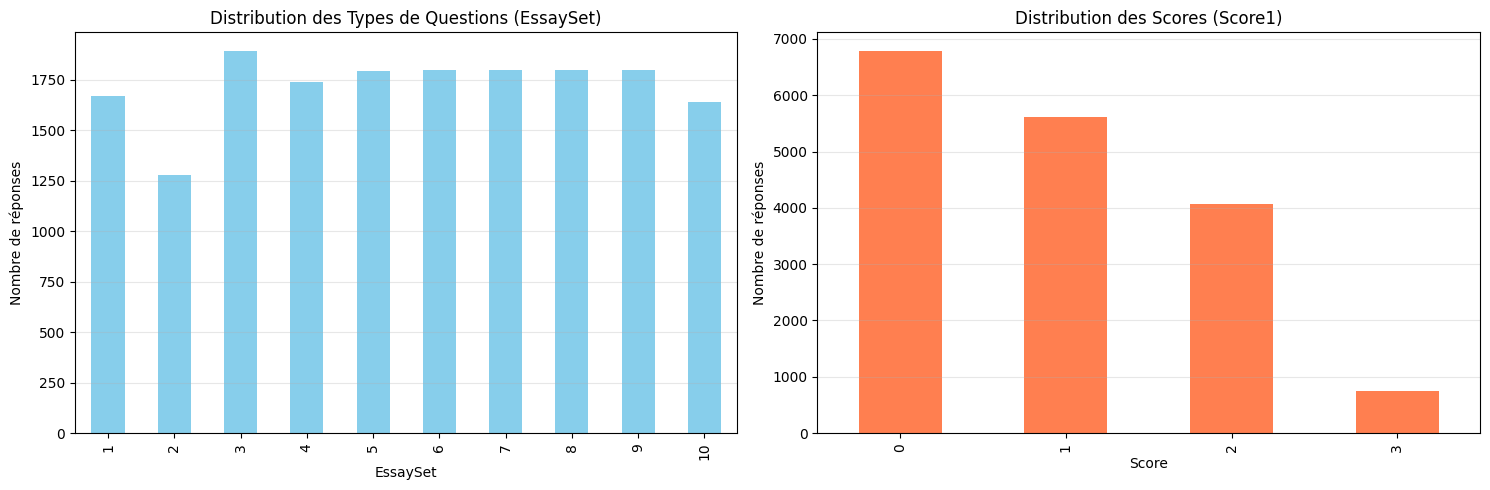

In [26]:
# Vérifier les valeurs manquantes
print("- Valeurs manquantes :")
print(df.isnull().sum())

# Distribution des EssaySet
print("\n- Distribution des types de questions (EssaySet) :")
essay_set_dist = df['EssaySet'].value_counts().sort_index()
print(essay_set_dist)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution des EssaySet
essay_set_dist.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Distribution des Types de Questions (EssaySet)')
axes[0].set_xlabel('EssaySet')
axes[0].set_ylabel('Nombre de réponses')
axes[0].grid(axis='y', alpha=0.3)

# Distribution des scores
score_dist = df['Score1'].value_counts().sort_index()
score_dist.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Distribution des Scores (Score1)')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Nombre de réponses')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# Corrélation entre Score1 et Score2
correlation, p_value = pearsonr(df['Score1'], df['Score2'])
print(f"\n🔗 Corrélation Score1 vs Score2 : {correlation:.3f}")




🔗 Corrélation Score1 vs Score2 : 0.913


### ***Choix du score de référence***

Dans ce projet, nous utilisons **`Score1` comme score final**, car il correspond à la note officielle attribuée à l’essai et c’est celle que le modèle doit prédire.
**`Score2`** sert uniquement à vérifier l’accord entre les correcteurs et n’est pas utilisé pour l’entraînement.

-------

In [31]:
# Vérifier la présence de marques de paragraphe ^P
has_p_marker = df['EssayText'].str.contains('\^[Pp]', regex=True)
count_with_p = has_p_marker.sum()
percentage_with_p = (count_with_p / len(df)) * 100

print(f"\n-> Réponses contenant ^P : {count_with_p} ({percentage_with_p:.1f}%)")
print(" Ces marques doivent être gérées dans le prétraitement !")

# Exemple d'une réponse avec ^P
if count_with_p > 0:
    example_with_p = df[has_p_marker].iloc[0]['EssayText']
    print(f"\n- Exemple avec ^P :")
    print(example_with_p[:200], "...")


-> Réponses contenant ^P : 732 (4.3%)
 Ces marques doivent être gérées dans le prétraitement !

- Exemple avec ^P :
1). Get 4 different samples: marble, limestone, wood, plastic. ^p 2). Put each sample into 4 different containers. ^p 3). Pour vinegar in each of 4 separate but identical containers. ^p 4). After 24 h ...


<>:2: SyntaxWarning: invalid escape sequence '\^'
<>:2: SyntaxWarning: invalid escape sequence '\^'
/tmp/ipython-input-2375106431.py:2: SyntaxWarning: invalid escape sequence '\^'
  has_p_marker = df['EssayText'].str.contains('\^[Pp]', regex=True)


## Analyse du Déséquilibre des Classes

**Point important** : Les scores ne sont pas équilibrés. Ce déséquilibre sera géré avec le **class weighting** lors de l'entraînement.

- Distribution des scores (Score1) :
  Score 0:  6779 ( 39.4%)
  Score 1:  5612 ( 32.6%)
  Score 2:  4075 ( 23.7%)
  Score 3:   741 (  4.3%)


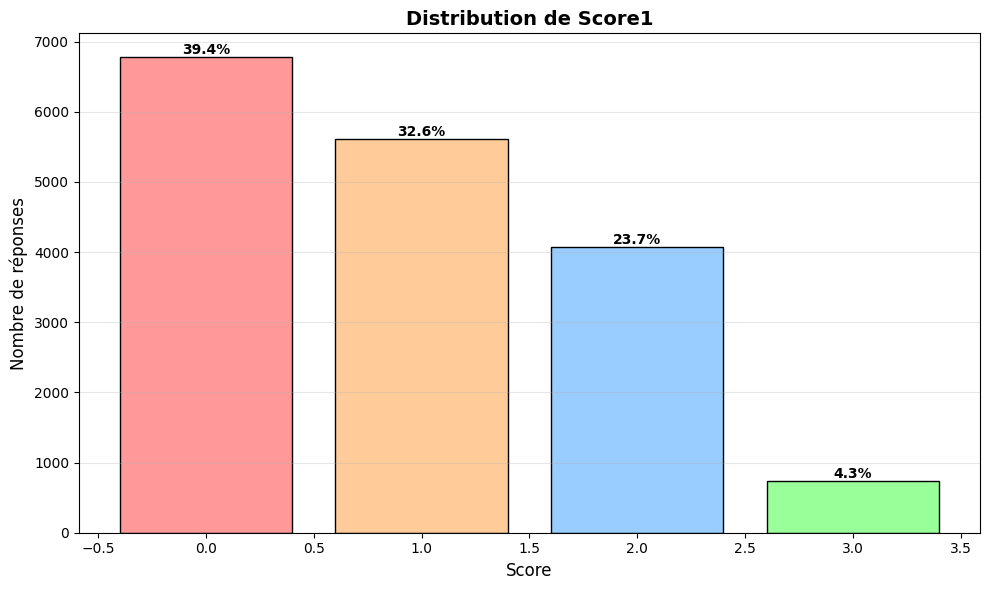

In [32]:
# Distribution détaillée des scores
print("- Distribution des scores (Score1) :")
for score in sorted(df['Score1'].unique()):
    count = (df['Score1'] == score).sum()
    percentage = (count / len(df)) * 100
    print(f"  Score {score}: {count:5d} ({percentage:5.1f}%)")

# Visualisation avec pourcentages
plt.figure(figsize=(10, 6))
score_counts = df['Score1'].value_counts().sort_index()
colors = ['#ff9999', '#ffcc99', '#99ccff', '#99ff99']
bars = plt.bar(score_counts.index, score_counts.values, color=colors, edgecolor='black')

# Ajouter les pourcentages sur les barres
for bar, score in zip(bars, score_counts.index):
    height = bar.get_height()
    percentage = (height / len(df)) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{percentage:.1f}%',
             ha='center', va='bottom', fontweight='bold')

plt.title('Distribution de Score1', fontsize=14, fontweight='bold')
plt.xlabel('Score', fontsize=12)
plt.ylabel('Nombre de réponses', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Point important** : Nous observons que les scores ne sont pas équilibrés. Les scores 0, 1, et 2 sont beaucoup plus fréquents que le score 3. Ce déséquilibre sera pris en compte lors de l'entraînement grâce au **class weighting**.